In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split   
df=pd.read_csv(r'preprocessed_data_1.csv')
print(df.head())

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0  146.412162             360.0   
1             4583             1508.0  128.000000             360.0   
2             3000                0.0   66.000000             360.0   
3             2583             2358.0  120.000000             360.0   
4             6000                0.0  141.000000             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0   

In [35]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')

In [36]:
df.dtypes

Loan_ID                  str
Gender                   str
Married                  str
Dependents               str
Education                str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area            str
Loan_Status              str
dtype: object

Intercept:  [0.98488345]
Coefficients:  [[-0.00102646]]

Accuracy: 0.6504065040650406

Actual vs Predicted Loan Status
   LoanAmount Actual Loan_Status Predicted Loan_Status
0       228.0                  Y                     Y
1       130.0                  Y                     Y
2       158.0                  Y                     Y
3        71.0                  Y                     Y
4        70.0                  Y                     Y
5       107.0                  Y                     Y
6       120.0                  Y                     Y
7        66.0                  Y                     Y
8       173.0                  N                     Y
9       110.0                  N                     Y


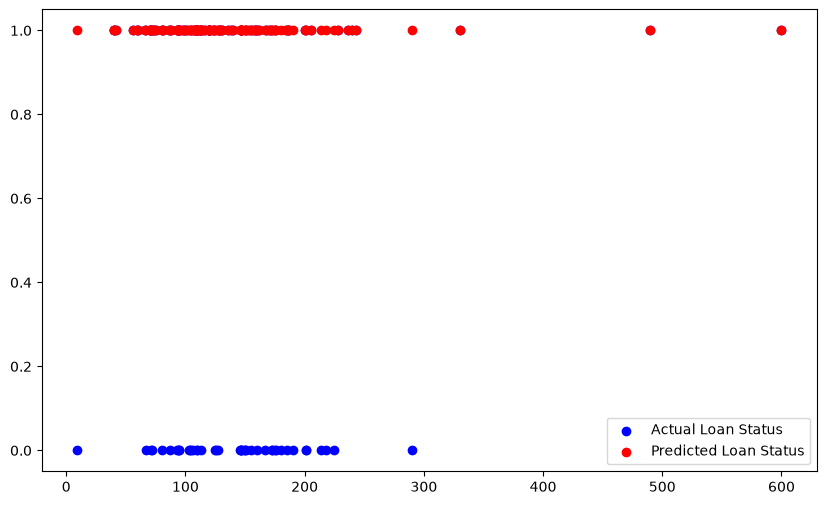

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Features and target
X = df[['LoanAmount']]
y = df['Loan_Status']

# Convert target Y/N into numeric values
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Create Logistic Regression model
model = LogisticRegression(max_iter=1000)

# Train the model
model.fit(X_train, y_train)

# Display intercept and coefficient
print("Intercept: ", model.intercept_)
print("Coefficients: ", model.coef_)

# Make predictions
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)

# Convert numeric predictions back to Y/N
actual_status = label_encoder.inverse_transform(y_test)
predicted_status = label_encoder.inverse_transform(y_pred)

# Create results DataFrame
results = pd.DataFrame({
    'LoanAmount': X_test['LoanAmount'].values,
    'Actual Loan_Status': actual_status,
    'Predicted Loan_Status': predicted_status
})

print("\nActual vs Predicted Loan Status")
print(results.head(10))

# Plot actual vs predicted
plt.figure(figsize=(10, 6))

plt.scatter(
    X_test['LoanAmount'],
    y_test,
    color='blue',
    label='Actual Loan Status'
)

plt.scatter(
    X_test['LoanAmount'],
    y_pred,
    color='red',
    label='Predicted Loan Status'
)

plt.xlabel = ('Loan Amount')
plt.ylabel = ('Loan Status')
plt.title = ('Actual vs Predicted Loan Status')
plt.legend()
plt.show()

In [ ]:
new_data